In [7]:
#stage 1

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import glob
import cv2
import pandas as pd



plt.ion()   # interactive mode

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
Dataset extracted.

TRAIN
NORMAL: 1341
PNEUMONIA: 3875

VAL
NORMAL: 8
PNEUMONIA: 8

TEST
NORMAL: 234
PNEUMONIA: 390


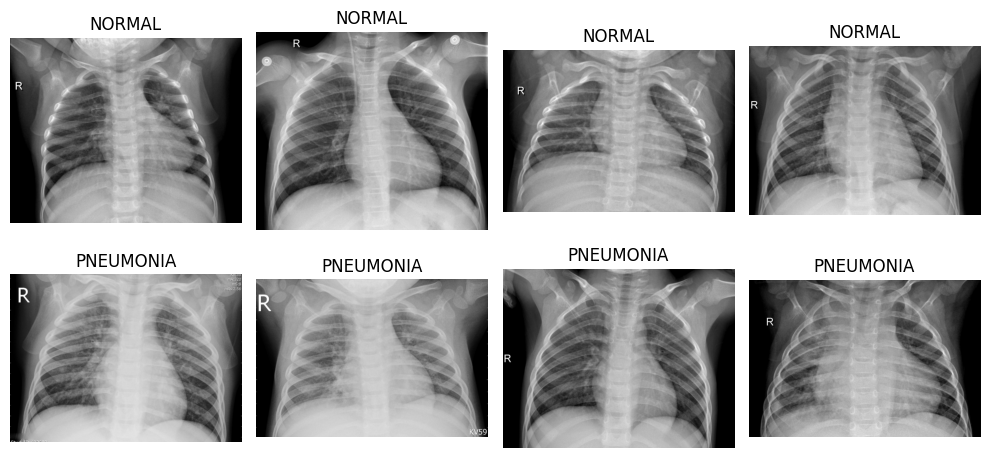

In [ ]:
# STAGE 2: Dataset Setup & Exploration (CLEAN)


from google.colab import drive
drive.mount('/content/drive')


# 2. Extract ZIP from Drive
# ------------------------------------------------------------
import zipfile

ZIP_PATH = "/content/drive/MyDrive/ML_Datasets /chest-xray-pneumonia.zip"
EXTRACT_PATH = "/content/data"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted.")

# ------------------------------------------------------------
# 3. Dataset Root
# ------------------------------------------------------------

DATA_ROOT = "/content/data/chest_xray"

SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

# ------------------------------------------------------------
# 4. Count images
# ------------------------------------------------------------
for split in SPLITS:
    print(f"\n{split.upper()}")
    for cls in CLASSES:
        folder = os.path.join(DATA_ROOT, split, cls)
        count = len(glob.glob(os.path.join(folder, "*.jpeg")) +
                    glob.glob(os.path.join(folder, "*.jpg")))
        print(f"{cls}: {count}")

# ------------------------------------------------------------
# 5. Show sample images (TRAIN only)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_ROOT, "train", cls)
    images = glob.glob(os.path.join(folder, "*.jpeg"))[:4]

    for col, img_path in enumerate(images):
        img = plt.imread(img_path)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        axes[row, col].set_title(cls)

plt.tight_layout()
plt.show()

In [ ]:
# stage 3
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

DATA_ROOT = "/content/data/chest_xray"
IMG_SIZE = 224
BATCH_SIZE = 32

CLASS_TO_IDX = {"NORMAL": 0, "PNEUMONIA": 1}
class_names = ["NORMAL", "PNEUMONIA"]
# ------------------------------------------------------------
# Transforms
# ------------------------------------------------------------
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
class ChestXRayDataset(Dataset):
    def __init__(self, split, transform=None):
        self.transform = transform
        self.samples = []

        for cls, idx in CLASS_TO_IDX.items():
            folder = os.path.join(DATA_ROOT, split, cls)
            images = glob.glob(os.path.join(folder, "*.jpeg"))

            for img in images:
                self.samples.append((img, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
train_dataset = ChestXRayDataset("train", train_transforms)
val_dataset   = ChestXRayDataset("val", eval_transforms)
test_dataset  = ChestXRayDataset("test", eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

dataloaders = {
    "train": train_loader,
    "val": val_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset)
}

In [ ]:
## stage 4 Create Function to Train Model

def train_model(model, criterion, optimizer, scheduler,
                dataloaders, dataset_sizes, device,
                num_epochs=32):


    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):

        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since

    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [ ]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis("off")

# ------------------------------------------------------------
# Function: visualize model predictions
# ------------------------------------------------------------
def visualize_predictions(model, dataloaders, device, num_images=9):

    model.eval()
    images_so_far = 0

    fig = plt.figure(figsize=(10, 6))

    with torch.no_grad():
        for inputs, labels in dataloaders["val"]:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):

                images_so_far += 1

                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.set_title(
                    f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}"
                )
                ax.axis("off")

                imshow(inputs.cpu().data[i])

                if images_so_far == num_images:
                    plt.tight_layout()
                    return

    plt.tight_layout()
    plt.show()

In [ ]:
#stage 6  Fine Tuning the Convnet
model_ft = models.resnet50(pretrained=True)
num_ftrs = model_ft.fc.in_features

# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 2)
)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


In [ ]:
# Train and Evaluate
model_ft = train_model(
    model=model_ft,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=15
)

Epoch 0/14
----------
train Loss: 0.1883 Acc: 0.9262
val Loss: 0.3308 Acc: 0.8125

Epoch 1/14
----------
train Loss: 0.0746 Acc: 0.9730
val Loss: 0.0770 Acc: 1.0000

Epoch 2/14
----------
train Loss: 0.0560 Acc: 0.9795
val Loss: 0.5041 Acc: 0.7500

Epoch 3/14
----------
train Loss: 0.0480 Acc: 0.9837
val Loss: 0.0585 Acc: 1.0000

Epoch 4/14
----------
train Loss: 0.0357 Acc: 0.9879
val Loss: 0.0744 Acc: 1.0000

Epoch 5/14
----------
train Loss: 0.0344 Acc: 0.9883
val Loss: 0.0535 Acc: 1.0000

Epoch 6/14
----------
train Loss: 0.0265 Acc: 0.9904
val Loss: 0.1734 Acc: 0.9375

Epoch 7/14
----------
train Loss: 0.0268 Acc: 0.9919
val Loss: 0.1137 Acc: 0.9375

Epoch 8/14
----------
train Loss: 0.0184 Acc: 0.9946
val Loss: 0.0990 Acc: 0.9375

Epoch 9/14
----------
train Loss: 0.0223 Acc: 0.9923
val Loss: 0.0946 Acc: 0.9375

Epoch 10/14
----------
train Loss: 0.0162 Acc: 0.9944
val Loss: 0.0439 Acc: 1.0000

Epoch 11/14
----------
train Loss: 0.0135 Acc: 0.9958
val Loss: 0.0571 Acc: 1.0000

Ep

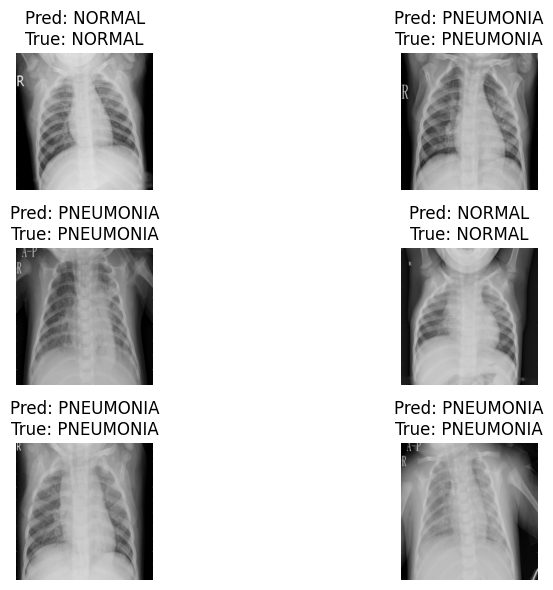

In [ ]:
from torch.utils.data import DataLoader

shuffled_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

visualize_predictions(model_ft, {"val": shuffled_val_loader}, device, num_images=6)

In [ ]:
#ConvNet as fixed feature extractor

model_conv = torchvision.models.resnet50(pretrained=True)

# We freeze layers here
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 2)
)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model_conv = train_model(model_conv,
                         criterion,
                         optimizer_conv,
                         exp_lr_scheduler,
                         dataloaders,
                         dataset_sizes,
                         device,
                         num_epochs=15)

Epoch 0/14
----------
train Loss: 0.3101 Acc: 0.8698
val Loss: 0.3475 Acc: 0.7500

Epoch 1/14
----------
train Loss: 0.2032 Acc: 0.9153
val Loss: 0.3131 Acc: 0.8750

Epoch 2/14
----------
train Loss: 0.1961 Acc: 0.9185
val Loss: 0.2762 Acc: 0.8750

Epoch 3/14
----------
train Loss: 0.1906 Acc: 0.9220
val Loss: 0.5199 Acc: 0.6875

Epoch 4/14
----------
train Loss: 0.1756 Acc: 0.9268
val Loss: 0.3303 Acc: 0.7500

Epoch 5/14
----------
train Loss: 0.1794 Acc: 0.9260
val Loss: 0.2105 Acc: 0.9375

Epoch 6/14
----------
train Loss: 0.1739 Acc: 0.9317
val Loss: 0.3427 Acc: 0.7500

Epoch 7/14
----------
train Loss: 0.1700 Acc: 0.9300
val Loss: 0.3422 Acc: 0.7500

Epoch 8/14
----------
train Loss: 0.1637 Acc: 0.9367
val Loss: 0.3011 Acc: 0.8125

Epoch 9/14
----------
train Loss: 0.1662 Acc: 0.9342
val Loss: 0.3051 Acc: 0.7500

Epoch 10/14
----------
train Loss: 0.1629 Acc: 0.9319
val Loss: 0.3225 Acc: 0.7500

Epoch 11/14
----------
train Loss: 0.1605 Acc: 0.9362
val Loss: 0.3132 Acc: 0.8125

Ep

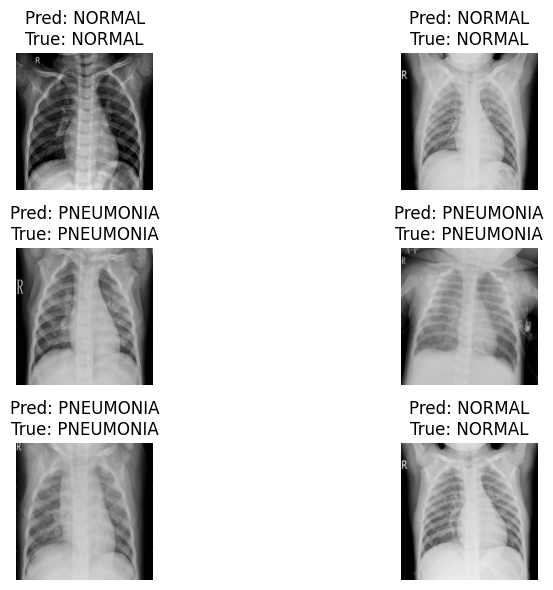

In [ ]:
from torch.utils.data import DataLoader

shuffled_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

visualize_predictions(model_conv, {"val": shuffled_val_loader}, device, num_images=6)


TEST RESULTS
----------------------------------------
Accuracy     : 0.9215
Precision    : 0.9128
Recall       : 0.9667
Specificity  : 0.8462
F1 Score     : 0.9390
ROC AUC      : 0.9683
TP=377 TN=198 FP=36 FN=13


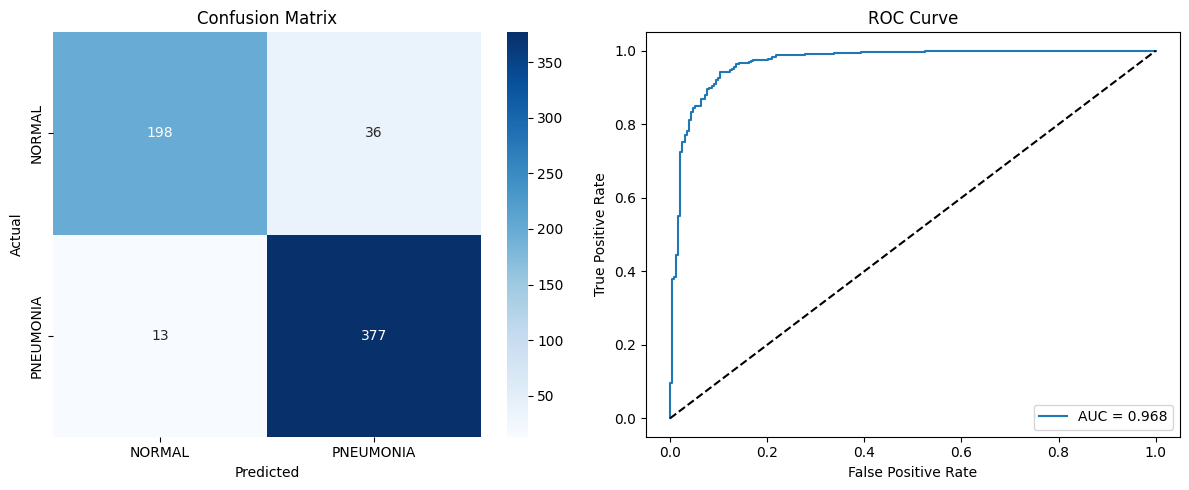

In [ ]:
# STAGE 6: Model Evaluation
# ============================================================


import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

model = model_ft

# ------------------------------------------------------------
# 6.1 Predictions
# ------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    y_true, y_probs, y_pred = [], [], []

    for inputs, labels in loader:
        inputs = inputs.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_probs.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_probs), np.array(y_pred)


y_true, y_probs, y_pred = get_predictions(model, test_loader, device)

# ------------------------------------------------------------
# 6.2 Metrics
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_probs)
specificity = tn / (tn + fp)

print("\nTEST RESULTS")
print("-" * 40)
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc_auc:.4f}")
print(f"TP={tp} TN={tn} FP={fp} FN={fn}")

# ------------------------------------------------------------
# 6.3 Confusion Matrix + ROC Curve
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_true, y_probs)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

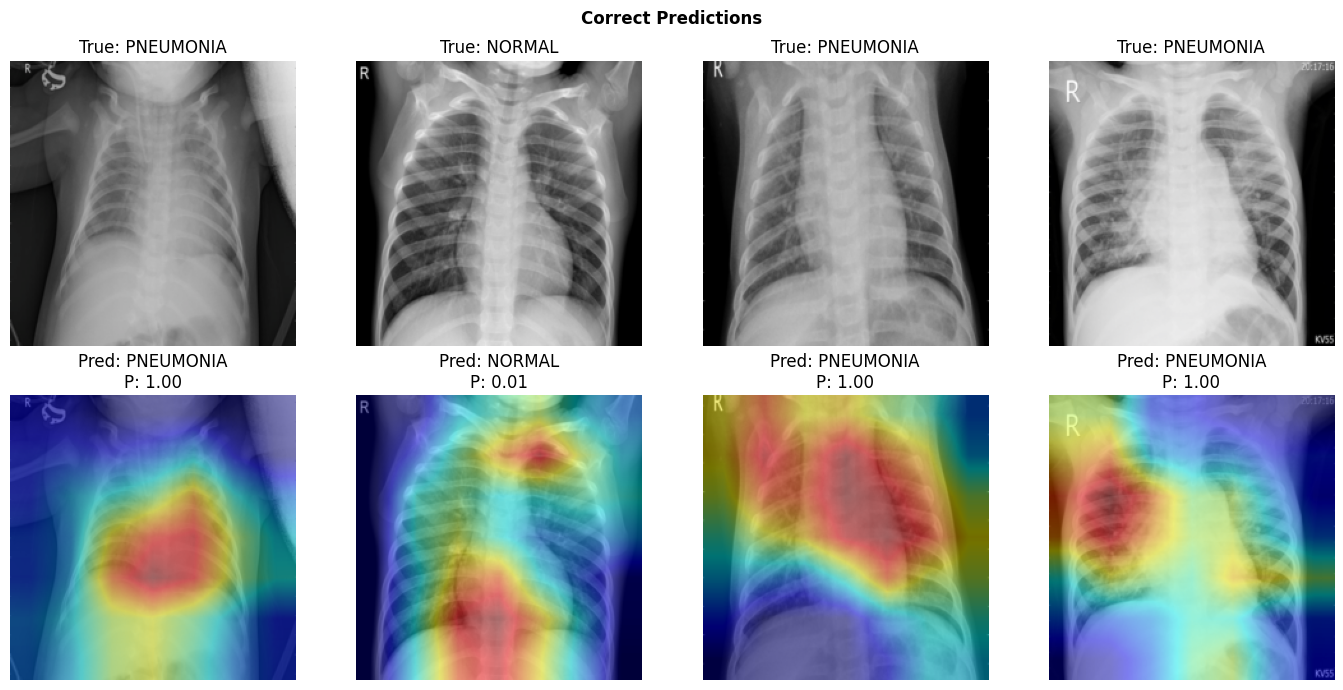

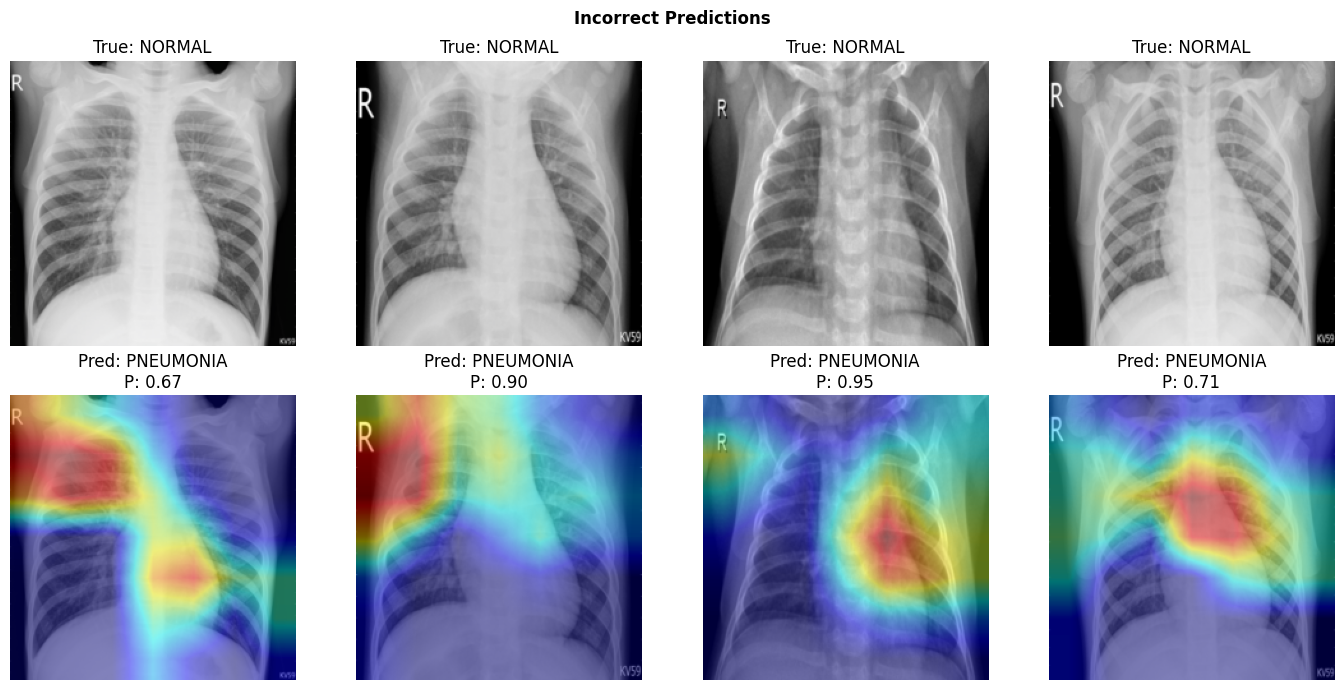

In [ ]:
# ============================================================
# STAGE 7: Grad-CAM Explainability
# ============================================================


import torch.nn.functional as F
from torch.utils.data import DataLoader

IDX_TO_CLASS = {0: "NORMAL", 1: "PNEUMONIA"}

MEAN = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
STD  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

# ------------------------------------------------------------
# Grad-CAM
# ------------------------------------------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x):
        self.model.zero_grad()

        out = self.model(x)
        pred = out.argmax(1).item()
        prob = torch.softmax(out, dim=1)[0, 1].item()

        out[0, pred].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, prob, pred

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def denormalize(img):
    img = img.cpu().numpy() * STD + MEAN
    return np.clip(img, 0, 1).transpose(1, 2, 0)

def overlay_heatmap(img, cam, alpha=0.45):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(alpha * heatmap + (1 - alpha) * img, 0, 1)

# ------------------------------------------------------------
# Collect samples
# ------------------------------------------------------------
gradcam = GradCAM(model, model.layer4[-1])
loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

correct, incorrect = [], []
model.eval()

for x, y in loader:
    cam, prob, pred = gradcam(x.to(device))
    true = y.item()

    rgb = denormalize(x.squeeze(0))

    sample = {
        "rgb": rgb,
        "cam": overlay_heatmap(rgb, cam),
        "true": IDX_TO_CLASS[true],
        "pred": IDX_TO_CLASS[pred],
        "prob": prob
    }

    if pred == true and len(correct) < 4:
        correct.append(sample)
    elif pred != true and len(incorrect) < 4:
        incorrect.append(sample)

    if len(correct) >= 4 and len(incorrect) >= 4:
        break

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
def plot_grid(data, title):
    n = len(data)
    fig, ax = plt.subplots(2, n, figsize=(3.5 * n, 7))
    fig.suptitle(title, fontweight="bold")

    for i, d in enumerate(data):
        ax[0, i].imshow(d["rgb"])
        ax[0, i].set_title(f"True: {d['true']}")
        ax[0, i].axis("off")

        ax[1, i].imshow(d["cam"])
        ax[1, i].set_title(f"Pred: {d['pred']}\nP: {d['prob']:.2f}")
        ax[1, i].axis("off")

    ax[0, 0].set_ylabel("Original")
    ax[1, 0].set_ylabel("Grad-CAM")

    plt.tight_layout()
    plt.show()

plot_grid(correct, "Correct Predictions")
plot_grid(incorrect, "Incorrect Predictions")

In [ ]:
# Model Comparison

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

# ------------------------------------------------------------
# Class weights (handle imbalance)
# ------------------------------------------------------------
n_normal = sum(1 for _, y in train_dataset.samples if y == 0)
n_pneu   = sum(1 for _, y in train_dataset.samples if y == 1)

class_weights = torch.tensor(
    [n_normal, n_pneu], dtype=torch.float32
).to(device)
class_weights = class_weights / class_weights.sum()

# ------------------------------------------------------------
# Model builder
# ------------------------------------------------------------
def build_model(name):
    if name == "resnet50":
        m = models.resnet50(weights="DEFAULT")
        m.fc = nn.Linear(m.fc.in_features, 2)

    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="DEFAULT")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 2)

    elif name == "densenet121":
        m = models.densenet121(weights="DEFAULT")
        m.classifier = nn.Linear(m.classifier.in_features, 2)

    else:
        raise ValueError("Unknown model")

    return m.to(device)

# ------------------------------------------------------------
# Train + evaluate
# ------------------------------------------------------------
def train_and_eval(name, epochs=5):

    model = build_model(name)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # freeze backbone
    for p in model.parameters():
        p.requires_grad = False

    head = model.fc if name == "resnet50" else model.classifier
    for p in head.parameters():
        p.requires_grad = True

    optimizer = optim.SGD(head.parameters(), lr=0.001, momentum=0.9)

    best_model = None
    best_acc = 0

    for epoch in range(epochs):
        for phase in ["train", "val"]:
            loader = train_loader if phase == "train" else val_loader
            model.train() if phase == "train" else model.eval()

            correct, total = 0, 0

            for x, y in loader:
                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    out = model(x)
                    loss = criterion(out, y)
                    preds = out.argmax(1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                correct += (preds == y).sum().item()
                total += y.size(0)

            acc = correct / total

            if phase == "val" and acc > best_acc:
                best_acc = acc
                best_model = model.state_dict()

        print(f"{name} | Epoch {epoch+1}/{epochs} | Val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model)

    # test evaluation
    y_true, y_probs, y_pred = get_predictions(model, test_loader, device)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_probs),
        "specificity": tn / (tn + fp)
    }

# ------------------------------------------------------------
# Run experiments
# ------------------------------------------------------------
results = {}

for m in ["resnet50", "efficientnet_b0", "densenet121"]:
    results[m] = train_and_eval(m, epochs=5)

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
df = pd.DataFrame(results).T.sort_values("f1", ascending=False)

print("\nMODEL COMPARISON")
print(df)

resnet50 | Epoch 1/5 | Val Acc: 0.5000
resnet50 | Epoch 2/5 | Val Acc: 0.5625
resnet50 | Epoch 3/5 | Val Acc: 0.5625
resnet50 | Epoch 4/5 | Val Acc: 0.5625
resnet50 | Epoch 5/5 | Val Acc: 0.5625
efficientnet_b0 | Epoch 1/5 | Val Acc: 0.6250
efficientnet_b0 | Epoch 2/5 | Val Acc: 0.6875
efficientnet_b0 | Epoch 3/5 | Val Acc: 0.7500
efficientnet_b0 | Epoch 4/5 | Val Acc: 0.7500
efficientnet_b0 | Epoch 5/5 | Val Acc: 0.7500
densenet121 | Epoch 1/5 | Val Acc: 0.8125
densenet121 | Epoch 2/5 | Val Acc: 0.8125
densenet121 | Epoch 3/5 | Val Acc: 0.8125
densenet121 | Epoch 4/5 | Val Acc: 1.0000
densenet121 | Epoch 5/5 | Val Acc: 1.0000

MODEL COMPARISON
                 accuracy  precision    recall        f1   roc_auc  \
densenet121      0.799679   0.765531  0.979487  0.859393  0.934024   
efficientnet_b0  0.775641   0.747036  0.969231  0.843750  0.911286   
resnet50         0.727564   0.701465  0.982051  0.818376  0.903156   

                 specificity  
densenet121         0.500000  
effi

In [1]:
## requierments
%%writefile requirements.txt
torch
torchvision
scikit-learn
seaborn
matplotlib
opencv-python
pandas
numpy

Writing requirements.txt


In [2]:
## gitignore
%%writefile .gitignore
.env
data/
__pycache__/
*.pyc
*.pth

Writing .gitignore


In [3]:
##README.md
%%writefile README.md
# Chest X-Ray Pneumonia Classification

Classifies chest X-ray images as **NORMAL** or **PNEUMONIA** using transfer
learning with CNNs, with explainability via Grad-CAM and a systematic
comparison of fine-tuning strategies and architectures.

## Dataset
[Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
— 5,856 pediatric chest X-ray images (anterior-posterior), labeled NORMAL or
PNEUMONIA, split into train/val/test sets.

**Note on the validation set**: the original Kaggle split's validation folder
contains only 16 images (8 per class). This causes validation accuracy to
swing dramatically between epochs (e.g. jumping to 100% then back down) —
not a sign of instability, just an artifact of too small a sample to be
statistically meaningful. All reported final results use the **test set**
(624 images), which gives a reliable signal.

## Approach

Three experiments were run to systematically compare training strategies:

1. **Full fine-tuning** (`model_ft`) — ResNet50 pretrained on ImageNet, all
   layers unfrozen and fine-tuned on chest X-rays.
2. **Frozen feature extractor** (`model_conv`) — ResNet50 with all
   convolutional layers frozen; only the final classification layer trained.
3. **Architecture comparison** — ResNet50, EfficientNet-B0, and DenseNet121,
   each trained with a frozen backbone (final layer only) for a fair,
   controlled comparison between architectures.

All models use `CrossEntropyLoss`, SGD optimizer, and a step learning-rate
scheduler. The architecture comparison additionally uses **class-weighted
loss** to address the dataset's class imbalance (more PNEUMONIA than NORMAL
images).

## Results

### Primary model: full fine-tuned ResNet50 (test set, 624 images)
| Metric | Value |
|---|---|
| Accuracy | 0.9215 |
| Precision | 0.9128 |
| Recall | **0.9667** |
| Specificity | 0.8462 |
| F1 Score | 0.9390 |
| ROC AUC | 0.9683 |

Confusion matrix: 377 true positives, 13 false negatives, 198 true negatives,
36 false positives.

### Fine-tuning strategy comparison (validation accuracy during training)
| Model | Best Val Acc | Notes |
|---|---|---|
| Full fine-tune (ResNet50) | 1.0000* | All layers trained |
| Frozen feature extractor (ResNet50) | 0.9375* | Only final layer trained |

*Val accuracy is on the 16-image validation set — see note above on
reliability; the gap in **training** accuracy (99.4% vs 93.5%) is the more
meaningful signal here, and confirms full fine-tuning learns considerably
better task-specific features.

### Architecture comparison (frozen backbone, test set)
| Model | Accuracy | Precision | Recall | F1 | ROC AUC | Specificity |
|---|---|---|---|---|---|---|
| **DenseNet121** | 0.800 | 0.766 | 0.979 | **0.859** | **0.934** | 0.500 |
| EfficientNet-B0 | 0.776 | 0.747 | 0.969 | 0.844 | 0.911 | 0.453 |
| ResNet50 (frozen) | 0.728 | 0.701 | 0.982 | 0.818 | 0.903 | 0.303 |

DenseNet121 was the strongest architecture under frozen-backbone conditions.
**Important**: none of these three match the fully fine-tuned ResNet50 above
(F1 0.86 vs 0.94) — they use a different, more constrained training strategy
(frozen backbone), so this comparison answers "which architecture works best
with limited compute/frozen features," not "which model is best overall."

## Key findings

- **Recall over precision, by design**: for a pneumonia screening tool,
  missing a real case (false negative) is more costly than a false alarm.
  The primary model reflects this priority (Recall 0.967 > Precision 0.913),
  catching 377 of 390 true pneumonia cases.
- **Full fine-tuning meaningfully outperforms frozen-backbone transfer
  learning** on this task — domain-specific features (X-ray texture patterns)
  differ enough from ImageNet's natural-image features that unfreezing the
  backbone provides a real, non-trivial improvement.
- **Grad-CAM revealed a spurious correlation risk**: on several false-positive
  cases (true NORMAL, predicted PNEUMONIA), the model's attention concentrated
  on non-diagnostic regions — image corner markers and shoulder/collarbone
  areas — rather than lung tissue. This suggests the model may partly rely on
  incidental acquisition artifacts rather than purely clinical features, a
  known and important risk in medical imaging models trained on datasets with
  inconsistent acquisition conditions across sources.
- **Frozen-backbone specificity was consistently low** (0.30–0.50 across all
  three architectures) — with only the final layer trainable, models struggle
  to correctly reject NORMAL cases, likely because ImageNet features aren't
  discriminative enough for this fine-grained medical distinction without
  further adaptation.

## Explainability
Grad-CAM was used to visualize which regions of each X-ray the model
attended to when making its prediction, for both correct and incorrect
predictions — see `notebook.ipynb` for the full visualization grid.

## Files
- `notebook.ipynb` — full pipeline: data loading, training (both strategies),
  evaluation, Grad-CAM, and architecture comparison
- `requirements.txt`
- `README.md`

## Setup
```bash
pip install -r requirements.txt
```

## Key learnings
- Always check validation set size before trusting per-epoch validation
  metrics — a 16-image val set produces noisy, unreliable signal even for a
  genuinely well-performing model.
- Explainability tools like Grad-CAM aren't just for presentation — they
  surfaced a real, actionable finding (potential reliance on non-clinical
  image artifacts) that pure metrics alone would have missed entirely.
- Fine-tuning strategy (frozen vs full) can matter more than architecture
  choice — a fully fine-tuned ResNet50 outperformed frozen-backbone
  DenseNet121, despite DenseNet's typically stronger baseline performance.

## Credits
Dataset: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
(Kermany et al., Mendeley Data). Pretrained models via `torchvision.models`.

Writing README.md


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
%cd "/content/drive/MyDrive/Colab Notebooks"

/content/drive/MyDrive/Colab Notebooks


In [18]:
!mkdir -p "/content/drive/MyDrive/chest-xray-pneumonia-classification/notebooks"
!mkdir -p "/content/drive/MyDrive/chest-xray-pneumonia-classification/results"